# Laboratorio 2: Estadistica Descriptiva Basica 2

Este notebook resuelve la actividad en dos partes:

- **Parte 1**: series de tiempo del par EUR/USD.
- **Parte 2**: analisis exploratorio del dataset *Breast Cancer Wisconsin (Diagnostic)*.



In [1]:
!pip install fitter --no-deps -q
!pip install click joblib loguru rich-click tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fitter 1.8.0 requires matplotlib>=3.10.7, but you have matplotlib 3.10.0 which is incompatible.
fitter 1.8.0 requires numpy>=2.2.6, but you have numpy 2.1.3 which is incompatible.
fitter 1.8.0 requires pandas>=2.3.3, but you have pandas 2.2.3 which is incompatible.


In [2]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from fitter import Fitter

sns.set_theme(style="whitegrid")

---
## Parte 1: Series de tiempo EUR/USD



### 1. Leer el dataset desde GitHub

In [3]:
url_eurusd = (
    "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/"
    "main/datasets/Pandas_data_historical_dataEURUSD.csv"
)
df_eurusd = pd.read_csv(url_eurusd)
df_eurusd.head()

,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


### 2. Definir la columna `time` como indice

In [4]:
df_eurusd["time"] = pd.to_datetime(df_eurusd["time"])
df_eurusd = df_eurusd.set_index("time")
df_eurusd.head()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


### 3. Informacion general del DataFrame

In [5]:
df_eurusd.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB


### 4. Determinar si hay valores null/NaN

In [6]:
conteo_nulos = df_eurusd.isnull().sum()
print(conteo_nulos)
print("Total de valores nulos en el DataFrame:", conteo_nulos.sum())

Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64
Total de valores nulos en el DataFrame: 0


### 5. Notacion PascalCase, trabajando solo con el precio de cierre

In [7]:
df_close = df_eurusd[["close"]].rename(columns={"close": "Close"})
df_close.head()

,Close
time,
2022-07-25 13:00:00,1.02345
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181


### 6. Mejor distribucion estadistica para la diferencia de precio

- Se agrega la columna `DiffPrice` (diferencia de precio hora a hora).
- Se construye el histograma de `DiffPrice`.
- Se usa `fitter` para encontrar la distribucion que mejor se ajusta.


In [8]:
df_diff = df_close.copy()
df_diff["DiffPrice"] = df_diff["Close"].diff()
df_diff = df_diff.dropna(subset=["DiffPrice"])  # la primera fila queda NaN
df_diff.head()

,Close,DiffPrice
time,,
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304
2022-07-25 18:00:00,1.02099,-0.00082


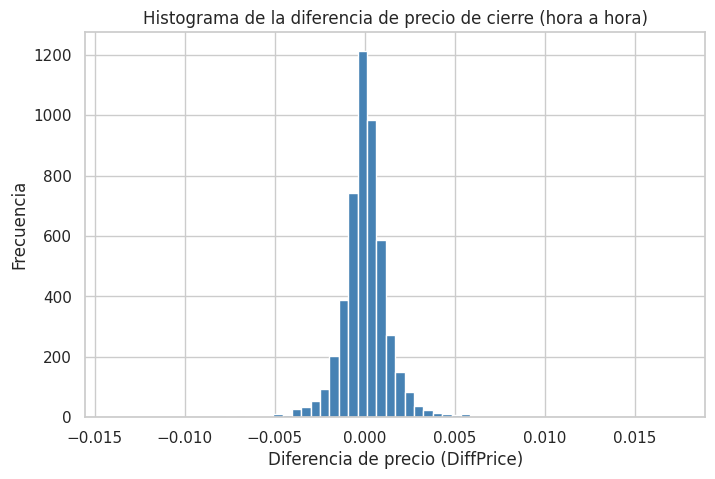

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_diff["DiffPrice"], bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Diferencia de precio (DiffPrice)")
plt.ylabel("Frecuencia")
plt.title("Histograma de la diferencia de precio de cierre (hora a hora)")
plt.show()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
lognorm,106500.661168,-51509.765589,-51490.214609,0.101912,0.091597,5.996555e-37
beta,106677.525909,-51503.229672,-51477.161699,0.102011,0.090756,2.794092e-36
norm,106744.023571,-51505.717419,-51492.683433,0.102054,0.090533,4.194767e-36
burr,721804.561088,-37765.252892,-37739.184919,7.480557,0.386409,0.000000e+00
gamma,923360.482403,-17723.242274,-17703.691294,14.865645,0.591356,0.000000e+00


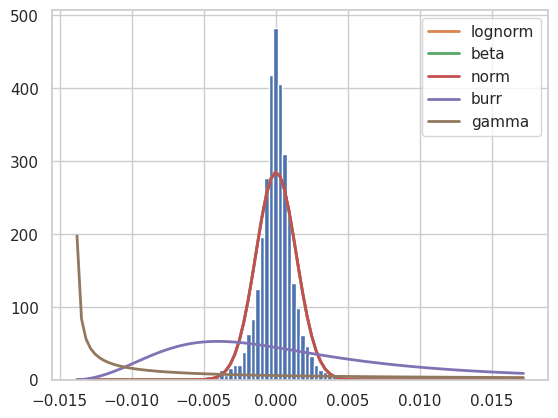

In [10]:
# Se usan las mismas distribuciones candidatas sugeridas en el enunciado
# para que el ajuste sea rapido.
distribuciones_candidatas = ["gamma", "lognorm", "beta", "burr", "norm"]
ajustador = Fitter(df_diff["DiffPrice"].values, distributions=distribuciones_candidatas)
ajustador.fit()
ajustador.summary()

In [11]:
mejor_distribucion = ajustador.get_best(method="sumsquare_error")
mejor_distribucion

{'lognorm': {'s': np.float64(0.009509964461157715),
  'loc': np.float64(-0.1471693008245066),
  'scale': np.float64(0.14717494036949658)}}

### 7. Seleccionar unicamente los datos de 2023

In [12]:
df_2023 = df_diff[df_diff.index.year == 2023]
print("Registros en 2023:", len(df_2023))
df_2023.head()

Registros en 2023: 2278


,Close,DiffPrice
time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016


### 8. Promedio con distintas periodicidades (15 dias, 1 semana, 1 mes)

In [13]:
promedio_15_dias = df_2023.groupby(pd.Grouper(freq="15D")).mean()
promedio_15_dias

,Close,DiffPrice
time,,
2023-01-02,1.069361,0.000047
2023-01-17,1.085565,0.000015
2023-02-01,1.077679,-0.000066
2023-02-16,1.063150,-0.000034
2023-03-03,1.063186,0.000026
2023-03-18,1.080936,0.000074
2023-04-02,1.093090,0.000063
2023-04-17,1.099084,-0.000006
2023-05-02,1.098889,-0.000059


In [14]:
promedio_semanal = df_2023.groupby(pd.Grouper(freq="1W")).mean()
promedio_semanal

,Close,DiffPrice
time,,
2023-01-08,1.059972,-0.000047
2023-01-15,1.076002,0.000156
2023-01-22,1.082041,0.000020
2023-01-29,1.088414,0.000010
2023-02-05,1.089281,-0.000062
2023-02-12,1.073363,-0.000097
2023-02-19,1.069648,0.000014
2023-02-26,1.063374,-0.000124
2023-03-05,1.060854,0.000073


In [15]:
promedio_mensual = df_2023.groupby(pd.Grouper(freq="1ME")).mean()
promedio_mensual

,Close,DiffPrice
time,,
2023-01-31,1.077463,0.000031
2023-02-28,1.071167,-0.000060
2023-03-31,1.070874,0.000049
2023-04-30,1.096051,0.000036
2023-05-31,1.098980,-0.000069


### 9. Histograma de `DiffPrice` para cada mes de 2023

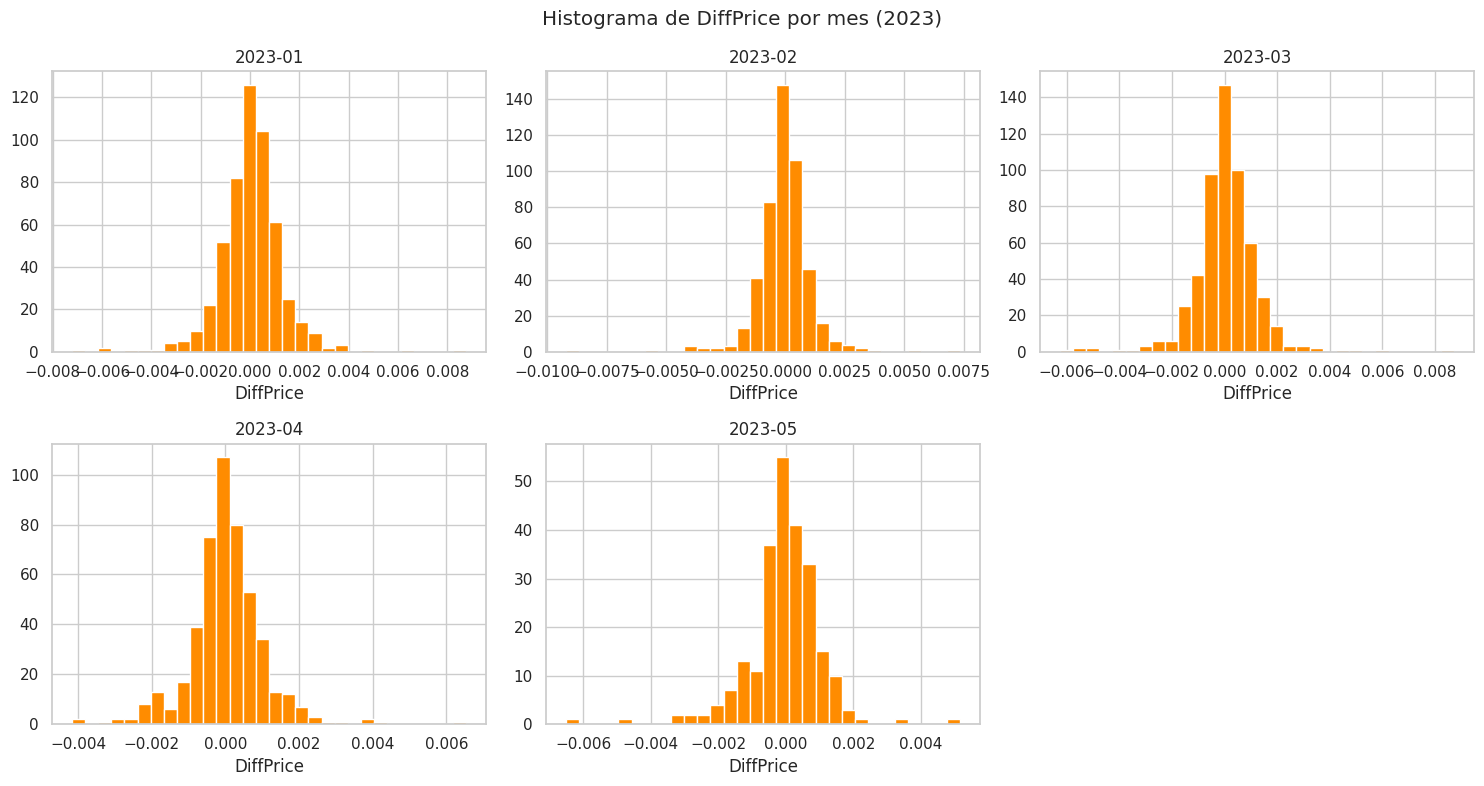

In [16]:
grupos_mensuales = df_2023.groupby(pd.Grouper(freq="1ME"))
meses_con_datos = [(nombre, grupo) for nombre, grupo in grupos_mensuales if len(grupo) > 0]

n_meses = len(meses_con_datos)
columnas_grid = 3
filas_grid = int(np.ceil(n_meses / columnas_grid))

fig, ejes = plt.subplots(filas_grid, columnas_grid, figsize=(15, 4 * filas_grid))
ejes = np.array(ejes).reshape(-1)

for eje, (nombre_mes, grupo_mes) in zip(ejes, meses_con_datos):
    eje.hist(grupo_mes["DiffPrice"], bins=30, color="darkorange", edgecolor="white")
    eje.set_title(nombre_mes.strftime("%Y-%m"))
    eje.set_xlabel("DiffPrice")

for eje_sobrante in ejes[n_meses:]:
    eje_sobrante.axis("off")

fig.suptitle("Histograma de DiffPrice por mes (2023)")
plt.tight_layout()
plt.show()

---
## Parte 2: Breast Cancer Wisconsin (Diagnostic)


In [17]:
from sklearn.datasets import load_breast_cancer

datos = load_breast_cancer()
df_cancer = pd.DataFrame(datos.data, columns=datos.feature_names)
# target: 0 = malignant, 1 = benign (segun sklearn) -> lo llevamos a "M"/"B"
df_cancer["diagnosis"] = np.where(datos.target == 0, "M", "B")
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


### 2. Renombrar las columnas en PascalCase

El dataset original repite 30 caracteristicas en 3 variantes: valor medio (`Mean`),
error estandar (`SE`) y peor valor (`Worst`).


In [18]:
nombres_base_pascal = {
    "radius": "Radius", "texture": "Texture", "perimeter": "Perimeter",
    "area": "Area", "smoothness": "Smoothness", "compactness": "Compactness",
    "concavity": "Concavity", "concave points": "ConcavePoints",
    "symmetry": "Symmetry", "fractal dimension": "FractalDimension",
}

def renombrar_columna_pascal_case(nombre_columna_sklearn):
    if nombre_columna_sklearn.startswith("mean "):
        base, sufijo = nombre_columna_sklearn.replace("mean ", ""), "Mean"
    elif nombre_columna_sklearn.endswith(" error"):
        base, sufijo = nombre_columna_sklearn.replace(" error", ""), "SE"
    elif nombre_columna_sklearn.startswith("worst "):
        base, sufijo = nombre_columna_sklearn.replace("worst ", ""), "Worst"
    else:
        base, sufijo = nombre_columna_sklearn, ""
    nombre_base_pascal = nombres_base_pascal.get(base, base.title().replace(" ", ""))
    return f"{nombre_base_pascal}{sufijo}"

mapa_nombres = {col: renombrar_columna_pascal_case(col) for col in df_cancer.columns if col != "diagnosis"}
mapa_nombres["diagnosis"] = "Diagnosis"
df_cancer = df_cancer.rename(columns=mapa_nombres)
df_cancer.columns.tolist()

['RadiusMean',
 'TextureMean',
 'PerimeterMean',
 'AreaMean',
 'SmoothnessMean',
 'CompactnessMean',
 'ConcavityMean',
 'ConcavePointsMean',
 'SymmetryMean',
 'FractalDimensionMean',
 'RadiusSE',
 'TextureSE',
 'PerimeterSE',
 'AreaSE',
 'SmoothnessSE',
 'CompactnessSE',
 'ConcavitySE',
 'ConcavePointsSE',
 'SymmetrySE',
 'FractalDimensionSE',
 'RadiusWorst',
 'TextureWorst',
 'PerimeterWorst',
 'AreaWorst',
 'SmoothnessWorst',
 'CompactnessWorst',
 'ConcavityWorst',
 'ConcavePointsWorst',
 'SymmetryWorst',
 'FractalDimensionWorst',
 'Diagnosis']

### 3. `head()`, `tail()`, `describe()` e `info()`

In [19]:
df_cancer.head()

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,...,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [20]:
df_cancer.tail()

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,...,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst,Diagnosis
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,B


In [21]:
df_cancer.describe()

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [22]:
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RadiusMean             569 non-null    float64
 1   TextureMean            569 non-null    float64
 2   PerimeterMean          569 non-null    float64
 3   AreaMean               569 non-null    float64
 4   SmoothnessMean         569 non-null    float64
 5   CompactnessMean        569 non-null    float64
 6   ConcavityMean          569 non-null    float64
 7   ConcavePointsMean      569 non-null    float64
 8   SymmetryMean           569 non-null    float64
 9   FractalDimensionMean   569 non-null    float64
 10  RadiusSE               569 non-null    float64
 11  TextureSE              569 non-null    float64
 12  PerimeterSE            569 non-null    float64
 13  AreaSE                 569 non-null    float64
 14  SmoothnessSE           569 non-null    float64
 15  Compac

### 4. Contar valores nulos/NaN

Si existieran, una estrategia razonable seria imputar con la **mediana** de cada columna
numerica (mas robusta a outliers que la media), o usar un `KNNImputer` si se sospecha
relacion entre variables.


In [23]:
conteo_nulos = df_cancer.isnull().sum()
print(conteo_nulos)
print("Total de valores nulos:", conteo_nulos.sum())

RadiusMean               0
TextureMean              0
PerimeterMean            0
AreaMean                 0
SmoothnessMean           0
CompactnessMean          0
ConcavityMean            0
ConcavePointsMean        0
SymmetryMean             0
FractalDimensionMean     0
RadiusSE                 0
TextureSE                0
PerimeterSE              0
AreaSE                   0
SmoothnessSE             0
CompactnessSE            0
ConcavitySE              0
ConcavePointsSE          0
SymmetrySE               0
FractalDimensionSE       0
RadiusWorst              0
TextureWorst             0
PerimeterWorst           0
AreaWorst                0
SmoothnessWorst          0
CompactnessWorst         0
ConcavityWorst           0
ConcavePointsWorst       0
SymmetryWorst            0
FractalDimensionWorst    0
Diagnosis                0
dtype: int64
Total de valores nulos: 0


### 5. Valores unicos de la columna `Diagnosis`

In [24]:
df_cancer["Diagnosis"].unique()

array(['M', 'B'], dtype=object)

### 6. Conteo de casos B y M con `seaborn.countplot()`

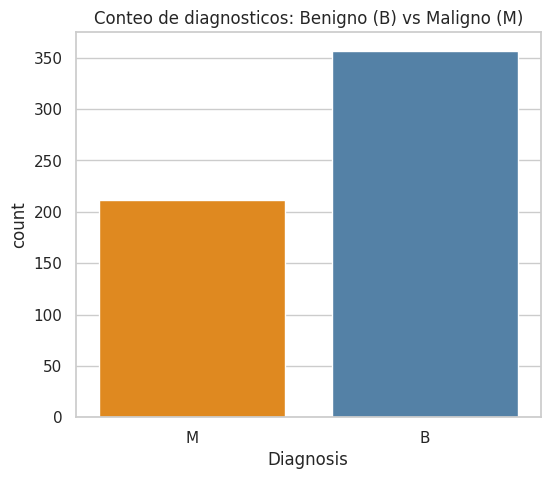

In [25]:
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df_cancer, x="Diagnosis", hue="Diagnosis",
    palette={"B": "steelblue", "M": "darkorange"}, legend=False,
)
plt.title("Conteo de diagnosticos: Benigno (B) vs Maligno (M)")
plt.show()

### 7. Columna `DiagnosisNumeric` (0 = Benigno, 1 = Maligno)

In [26]:
df_cancer["DiagnosisNumeric"] = df_cancer["Diagnosis"].map({"B": 0, "M": 1})
df_cancer[["Diagnosis", "DiagnosisNumeric"]].head()

,Diagnosis,DiagnosisNumeric
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


### 8. Normalizar columnas numericas: `(x - media) / desviacion estandar`

In [27]:
columnas_numericas = df_cancer.select_dtypes(include=[np.number]).columns
df_normalizado = df_cancer.copy()
df_normalizado[columnas_numericas] = df_cancer[columnas_numericas].apply(
    lambda columna: (columna - columna.mean()) / columna.std()
)
df_normalizado[columnas_numericas].describe().loc[["mean", "std"]]

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,...,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst,DiagnosisNumeric
mean,-1.311195e-16,6.243785e-17,-1.123881e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,2.497514e-17,-4.995028e-17,1.748260e-16,4.838933e-16,...,0.0,-3.496520e-16,1.248757e-17,-2.372638e-16,-3.246768e-16,8.741299e-17,2.247763e-16,2.747265e-16,-5.744282e-16,2.497514e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


### 9. Promedio por grupo de caracteristicas similares



In [28]:
patron_nombre_base = re.compile(r"^[A-Za-z]+?(?=(Mean|SE|Worst)$)")

grupos_por_base = {}
for columna in df_cancer.columns:
    coincidencia = patron_nombre_base.match(columna)
    if coincidencia:
        nombre_base = coincidencia.group(0)
        grupos_por_base.setdefault(nombre_base, []).append(columna)

df_promedios_por_grupo = pd.DataFrame({
    nombre_base: df_cancer[columnas_del_grupo].mean(axis=1)
    for nombre_base, columnas_del_grupo in grupos_por_base.items()
})
df_promedios_por_grupo.head()

,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,ConcavePoints,Symmetry,FractalDimension
0,14.821667,9.538433,105.329667,1057.800000,0.095666,0.330747,0.355243,0.142790,0.244010,0.067934
1,15.367833,13.971300,98.366000,1118.693333,0.071255,0.092773,0.115700,0.089857,0.156697,0.049741
2,14.668533,15.855633,95.695000,1002.010000,0.086717,0.208153,0.228707,0.130493,0.196900,0.050714
3,8.941867,16.012000,59.965000,327.010000,0.120470,0.408260,0.328303,0.127123,0.327710,0.093216
4,14.529067,10.597100,97.579333,988.813333,0.083063,0.120803,0.218293,0.095217,0.144953,0.046908


### 10. Histograma de `RadiusMean` separado por diagnostico

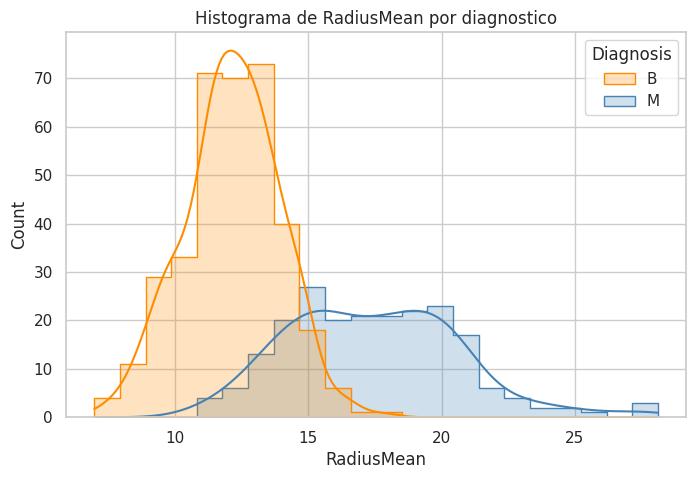

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_cancer, x="RadiusMean", hue="Diagnosis", hue_order=["B", "M"],
    palette={"B": "darkorange", "M": "steelblue"}, kde=True, element="step",
)
plt.title("Histograma de RadiusMean por diagnostico")
plt.show()

### 11. Graficos de violin para multiples caracteristicas

`SymmetryWorst` y `FractalDimensionWorst` corresponden a `Symmetry3` y
`FractalDimension3` en la numeracion original del enunciado (1=Mean, 2=SE, 3=Worst).


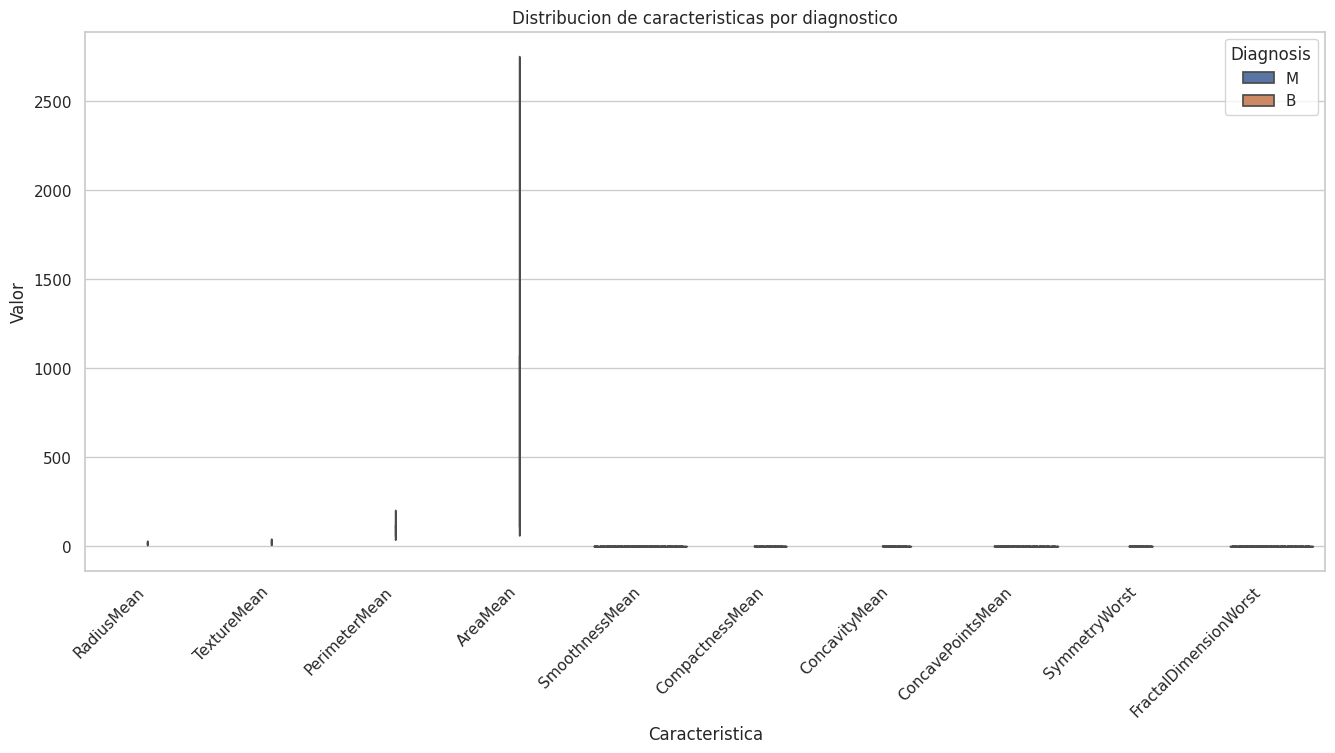

In [30]:
columnas_violin = [
    "RadiusMean", "TextureMean", "PerimeterMean", "AreaMean", "SmoothnessMean",
    "CompactnessMean", "ConcavityMean", "ConcavePointsMean",
    "SymmetryWorst", "FractalDimensionWorst",
]

datos_para_violin = pd.melt(
    df_cancer[["Diagnosis"] + columnas_violin],
    id_vars="Diagnosis", var_name="Caracteristica", value_name="Valor",
)

plt.figure(figsize=(16, 7))
sns.violinplot(
    x="Caracteristica", y="Valor", hue="Diagnosis", data=datos_para_violin,
    split=True, inner="quart",
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribucion de caracteristicas por diagnostico")
plt.show()

### 12. Detectar y eliminar outliers en `RadiusMean` (IQR y Z-score)

<Figure size 1000x500 with 0 Axes>

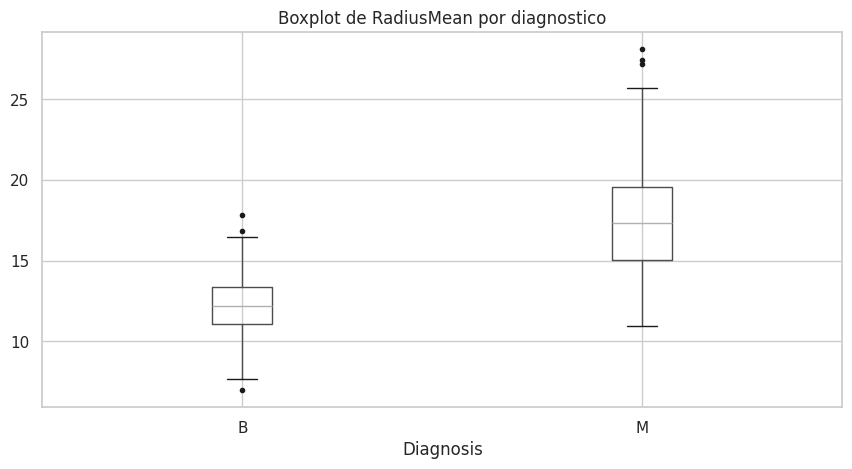

In [31]:
plt.figure(figsize=(10, 5))
df_cancer.boxplot(column="RadiusMean", by="Diagnosis", sym="k.", figsize=(10, 5))
plt.title("Boxplot de RadiusMean por diagnostico")
plt.suptitle("")
plt.show()

In [32]:
primer_cuartil = df_cancer["RadiusMean"].quantile(0.25)
tercer_cuartil = df_cancer["RadiusMean"].quantile(0.75)
rango_intercuartilico = tercer_cuartil - primer_cuartil

limite_inferior = primer_cuartil - 1.5 * rango_intercuartilico
limite_superior = tercer_cuartil + 1.5 * rango_intercuartilico

df_sin_outliers_iqr = df_cancer[
    ~((df_cancer["RadiusMean"] < limite_inferior) | (df_cancer["RadiusMean"] > limite_superior))
]
print("Registros originales:", len(df_cancer))
print("Sin outliers (IQR):", len(df_sin_outliers_iqr))
print("Eliminados:", len(df_cancer) - len(df_sin_outliers_iqr))

Registros originales: 569
Sin outliers (IQR): 555
Eliminados: 14


In [33]:
# Alternativa: deteccion de outliers con puntaje Z
puntajes_z = np.abs(stats.zscore(df_cancer["RadiusMean"]))
df_sin_outliers_zscore = df_cancer[puntajes_z < 3]
print("Registros originales:", len(df_cancer))
print("Sin outliers (Z-score):", len(df_sin_outliers_zscore))
print("Eliminados:", len(df_cancer) - len(df_sin_outliers_zscore))

Registros originales: 569
Sin outliers (Z-score): 564
Eliminados: 5


### 13. Matriz de correlacion y `heatmap`

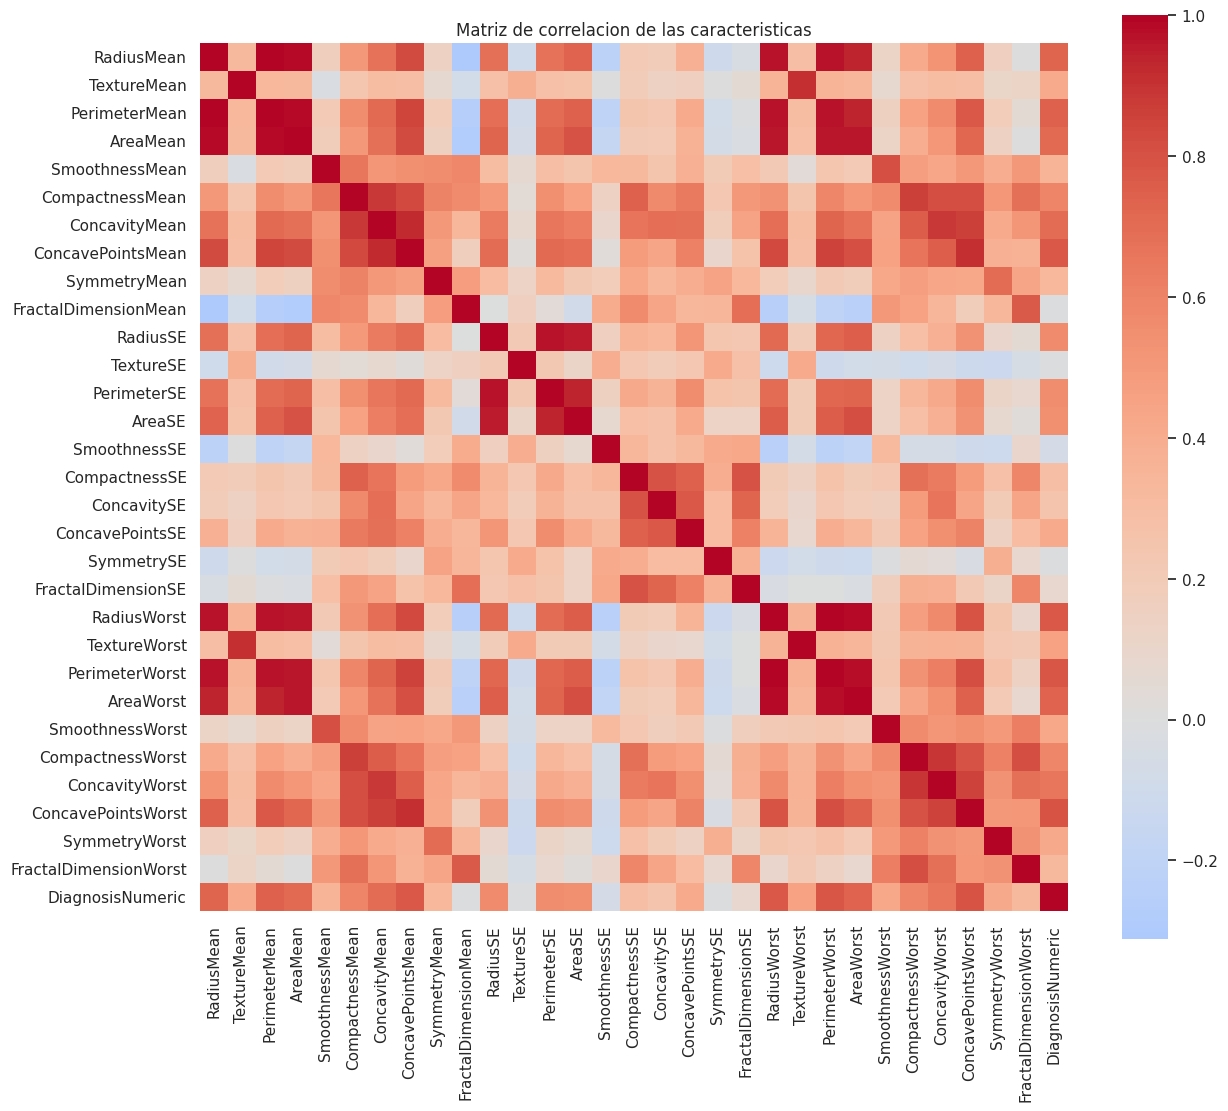

In [34]:
matriz_correlacion = df_cancer[columnas_numericas].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(matriz_correlacion, cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlacion de las caracteristicas")
plt.show()

### 14. ¿Que otros graficos pueden ayudar a entender mejor los datos?

- **Pairplot** (`sns.pairplot`) de un subconjunto de caracteristicas, coloreado por `Diagnosis`,
  para ver relaciones bivariadas y separabilidad entre clases.
- **PCA en 2D**, coloreado por `Diagnosis`, para visualizar la separabilidad en un espacio reducido.
- **Scatterplots** entre pares de caracteristicas muy correlacionadas (ej. `RadiusMean` vs
  `PerimeterMean`) para confirmar relaciones lineales.
- **Graficos de densidad** (`kdeplot`) superpuestos por clase, para comparar formas de
  distribucion sin el efecto del ancho de bin del histograma.
